# Steinbeck, jalopies e domanda costretta  

Questo notebook propone un **modello agent-based (ABM)** in Python pensato come **laboratorio teorico** per ragionare sul testo che hai fornito.

L'idea è distinguere tre livelli di spiegazione del mercato delle auto usate:

1. **Akerlof**: qualità eterogenea + informazione imperfetta.
2. **Steinbeck esteso**: alla selezione avversa si aggiungono **domanda costretta**, **potere locale dei venditori**, **discriminazione di prezzo**, **opportunismo one-shot**, e **vulnerabilità socio-antropologica dei compratori**.
3. **Correzione istituzionale**: standard minimi, ispezioni, sanzioni, garanzie.

Il notebook è costruito in modo che tu possa:

- usarlo come notebook didattico;
- metterlo online quasi direttamente;
- trasformarlo in mini-app con **Voilà**;
- adattarlo in seguito a una versione più empirica o più narrativa.

---

## Indice

1. Ipotesi teoriche  
2. Traduzione del testo in meccanismi agent-based  
3. Codice del modello  
4. Scenario base  
5. Confronto tra scenari  
6. Mappa di sensibilità dei parametri  
7. Explorer interattivo  
8. Come pubblicarlo online


## 1. Ipotesi teoriche

### 1.1. Perché non basta Akerlof
Nel modello classico dei **lemons**, la qualità non è osservabile bene ex ante.  
I compratori scontano il rischio di comprare beni cattivi, il prezzo medio scende, e i beni migliori tendono a uscire dal mercato.

Nel testo da cui partiamo, però, questo meccanismo **non è sufficiente**. Il mercato descritto è più duro e più concreto:

- i venditori hanno spesso **potere locale**;
- i compratori sono **molti**, vulnerabili e poco informati;
- la domanda è **costretta**: bisogna comprare comunque;
- il rapporto è spesso **one-shot**, quindi la reputazione conta poco;
- il venditore può **stimare il budget del cliente** e praticare prezzi differenziati;
- mancano **istituzioni neutralizzatrici** che impongano qualità minima.

### 1.2. Intuizione sostantiva
Nel nostro ABM il lemon non nasce solo da una media informativa sfavorevole.  
Può diventare il risultato di una **strategia profittevole di sfruttamento**, resa possibile da:

- bisogno urgente del compratore;
- debole capacità di ispezione;
- scarsa conoscenza delle regole di mercato;
- potere del venditore nel mercato locale;
- assenza di vincoli istituzionali.

### 1.3. Cosa vogliamo osservare
Le metriche principali saranno:

- quota di **lemons vendute**;
- quota di offerta **buona**;
- **deception** media: differenza tra qualità percepita e qualità effettiva;
- **prezzo medio**;
- **benessere del compratore**;
- **fallimenti del viaggio** (quando si compra un lemon troppo scadente);
- **profitto totale** dei venditori.

> Questo non è un modello di stima empirica. È un **dispositivo teorico-computazionale**: serve a pensare meglio le ipotesi del testo.


## 2. Dal testo al modello

### 2.1. Agenti

#### Compratori
Ogni compratore ha:
- **budget**;
- **urgenza**;
- **market literacy**;
- **inspection skill**;
- **fiducia** iniziale;
- memoria di cattive esperienze.

#### Venditori
Ogni venditore ha:
- una **reputazione** iniziale;
- una strategia implicita su:
  - quota di lemons in offerta,
  - markup,
  - aggressività commerciale,
  - discriminazione di prezzo.

#### Istituzioni
Rappresentiamo le istituzioni come parametri che agiscono sul comportamento del mercato:
- forza dell'enforcement;
- probabilità di ispezione;
- standard minimi di qualità;
- sanzioni;
- rimborso/garanzia.

### 2.2. Meccanismi chiave

1. Il venditore decide se offrire un'auto buona o un lemon.  
2. Formula un prezzo che dipende da:
   - potere locale,
   - aggressività,
   - discriminazione di prezzo,
   - qualità offerta.
3. Il compratore osserva un **segnale rumoroso** della qualità.
4. La decisione di acquisto dipende da:
   - qualità percepita,
   - affordability,
   - fiducia,
   - domanda costretta.
5. Se compra un lemon, il compratore può subire perdita di welfare e fallimento del viaggio.
6. Se le istituzioni sono più forti, il comportamento predatorio diventa meno conveniente.

### 2.3. Lettura economica
Il modello consente di ragionare su una tesi precisa:

> **La cattiva qualità può prevalere non soltanto per selezione avversa, ma perché in certi contesti storici e sociali essa diventa la strategia razionale del venditore.**


In [1]:
from dataclasses import dataclass, asdict
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)


In [2]:
@dataclass
class Params:
    # Struttura del mercato
    n_buyers: int = 700
    n_sellers: int = 28
    periods: int = 60  # numero di round settimanali della simulazione
    time_unit: str = "1 period = 1 market week"

    # Costi e qualità tecnica
    cost_good: float = 70.0
    cost_lemon: float = 25.0
    durability_good: float = 0.88
    durability_lemon: float = 0.28

    # Domanda e vulnerabilità
    forced_demand: float = 0.78
    income_dispersion: float = 22.0
    literacy_mean: float = 0.38
    inspection_mean: float = 0.32
    trust_mean: float = 0.66

    # Lato offerta
    local_market_power: float = 0.78
    seller_aggressiveness: float = 0.72
    price_discrimination: float = 0.62
    lemon_push: float = 0.68

    # Istituzioni
    institution_strength: float = 0.08
    inspection_probability: float = 0.05
    min_quality_standard: float = 0.00
    penalty_if_caught: float = 22.0
    warranty_refund_share: float = 0.00

params = Params()
params


Params(n_buyers=700, n_sellers=28, periods=60, time_unit='1 period = 1 market week', cost_good=70.0, cost_lemon=25.0, durability_good=0.88, durability_lemon=0.28, forced_demand=0.78, income_dispersion=22.0, literacy_mean=0.38, inspection_mean=0.32, trust_mean=0.66, local_market_power=0.78, seller_aggressiveness=0.72, price_discrimination=0.62, lemon_push=0.68, institution_strength=0.08, inspection_probability=0.05, min_quality_standard=0.0, penalty_if_caught=22.0, warranty_refund_share=0.0)

In [3]:
class Buyer:
    def __init__(self, idx, p: Params):
        self.idx = idx
        self.budget = np.clip(np.random.normal(95, p.income_dispersion), 30, 190)
        self.urgency = np.clip(np.random.beta(5, 2), 0, 1)
        self.market_literacy = np.clip(np.random.normal(p.literacy_mean, 0.16), 0, 1)
        self.inspection_skill = np.clip(np.random.normal(p.inspection_mean, 0.16), 0, 1)
        self.trust = np.clip(np.random.normal(p.trust_mean, 0.12), 0, 1)
        self.bad_experiences = 0
        self.has_car = False
        self.failed_trip = False

    @property
    def vulnerability(self):
        v = (
            0.45 * self.urgency
            + 0.30 * (1 - self.market_literacy)
            + 0.25 * (1 - self.inspection_skill)
        )
        return float(np.clip(v, 0, 1))

    def update_after_purchase(self, got_lemon: bool):
        if got_lemon:
            self.bad_experiences += 1
            self.trust = max(0, self.trust - 0.10)
        else:
            self.trust = min(1, self.trust + 0.02)


class Seller:
    def __init__(self, idx, p: Params):
        self.idx = idx
        self.p = p
        self.reputation = np.clip(np.random.normal(0.50, 0.12), 0, 1)
        self.cash = 0.0

    def choose_quality_mix(self):
        pressure = (
            0.50 * self.p.lemon_push
            + 0.35 * self.p.local_market_power
            + 0.15 * (1 - self.reputation)
        )
        share_lemons = np.clip(np.random.normal(pressure, 0.08), 0.05, 0.95)
        return share_lemons

    def quote_price(self, buyer, quality):
        base = 92 if quality == "good" else 72

        market_markup = 1 + 0.45 * self.p.local_market_power
        discr = 1 + self.p.price_discrimination * (
            0.55 * (buyer.budget / 140) + 0.45 * buyer.vulnerability
        )
        aggression = 1 + self.p.seller_aggressiveness * (0.18 if quality == "good" else 0.28)
        institution_discount = 1 - 0.20 * self.p.institution_strength

        price = base * market_markup * discr * aggression * institution_discount
        min_cost = self.p.cost_good if quality == "good" else self.p.cost_lemon
        return max(min_cost * 1.03, price)


In [4]:
class UsedCarMarketABM:
    def __init__(self, p: Params, seed: int = 42):
        self.p = p
        self.seed = seed
        np.random.seed(seed)
        random.seed(seed)
        self.sellers = [Seller(i, p) for i in range(p.n_sellers)]
        self.history = []

    def perceived_quality(self, buyer, true_quality):
        q_true = self.p.durability_good if true_quality == "good" else self.p.durability_lemon
        signal_precision = 0.15 + 0.70 * buyer.inspection_skill + 0.15 * buyer.market_literacy
        noise_scale = max(0.02, 0.22 * (1 - signal_precision))
        perceived = np.clip(np.random.normal(q_true, noise_scale), 0, 1)
        return perceived

    def purchase_probability(self, buyer, price, perceived_quality):
        affordability = np.clip(1 - max(0, price - buyer.budget) / max(buyer.budget, 1), 0, 1)
        utility_signal = 0.55 * perceived_quality + 0.25 * buyer.trust + 0.20 * affordability
        forced_component = self.p.forced_demand * buyer.urgency

        decision_score = (
            0.45 * utility_signal
            + 0.40 * forced_component
            + 0.15 * (1 - buyer.bad_experiences / 5)
        )
        return float(np.clip(decision_score, 0, 1))

    def seller_offer(self, seller, buyer):
        share_lemons = seller.choose_quality_mix()
        quality = "lemon" if np.random.rand() < share_lemons else "good"

        if quality == "lemon" and self.p.min_quality_standard > 0:
            if (
                self.p.durability_lemon < self.p.min_quality_standard
                and np.random.rand() < self.p.institution_strength
            ):
                quality = "good"

        price = seller.quote_price(buyer, quality)
        return quality, price, share_lemons

    def institutional_outcome(self, seller, quality):
        penalty = 0.0
        refund = 0.0
        if quality == "lemon" and np.random.rand() < self.p.inspection_probability * self.p.institution_strength:
            penalty = self.p.penalty_if_caught
            refund = self.p.warranty_refund_share
            seller.reputation = max(0, seller.reputation - 0.04)
        return penalty, refund

    def step(self, t):
        buyers = [Buyer(i + t * self.p.n_buyers, self.p) for i in range(self.p.n_buyers)]

        transactions = 0
        lemons_sold = 0
        good_sold = 0
        total_price = 0.0
        total_profit = 0.0
        total_buyer_welfare = 0.0
        deceptions = 0
        failed_trips = 0
        no_purchase = 0
        seller_mix = []

        for buyer in buyers:
            seller = random.choice(self.sellers)
            quality, price, mix = self.seller_offer(seller, buyer)
            seller_mix.append(mix)

            perceived_quality = self.perceived_quality(buyer, quality)
            p_buy = self.purchase_probability(buyer, price, perceived_quality)

            if np.random.rand() < p_buy:
                buyer.has_car = True
                transactions += 1
                total_price += price

                if quality == "good":
                    cost = self.p.cost_good
                    durability = self.p.durability_good
                    good_sold += 1
                else:
                    cost = self.p.cost_lemon
                    durability = self.p.durability_lemon
                    lemons_sold += 1

                penalty, refund_share = self.institutional_outcome(seller, quality)
                refund = price * refund_share if quality == "lemon" else 0.0

                profit = price - cost - penalty - refund
                seller.cash += profit
                total_profit += profit

                use_value = durability * 120
                welfare = use_value - price + 18 * buyer.urgency
                if quality == "lemon" and durability < 0.35:
                    welfare -= 30
                    buyer.failed_trip = True
                    failed_trips += 1

                total_buyer_welfare += welfare
                deception = max(0, perceived_quality - durability)
                deceptions += deception

                buyer.update_after_purchase(got_lemon=(quality == "lemon"))
            else:
                no_purchase += 1
                if buyer.urgency > 0.75:
                    failed_trips += 1

        out = {
            "period": t,
            "transactions": transactions,
            "share_lemons_sold": lemons_sold / max(transactions, 1),
            "share_good_strategy": good_sold / max(transactions, 1),
            "avg_price": total_price / max(transactions, 1),
            "avg_buyer_welfare": total_buyer_welfare / max(transactions, 1),
            "avg_deception": deceptions / max(transactions, 1),
            "failed_trips": failed_trips,
            "no_purchase": no_purchase,
            "total_profit": total_profit,
            "avg_seller_lemon_mix": float(np.mean(seller_mix)) if seller_mix else np.nan,
        }
        self.history.append(out)
        return out

    def run(self):
        for t in range(self.p.periods):
            self.step(t)
        return pd.DataFrame(self.history)


In [5]:
def summarize_scenario(df):
    cols = [
        "share_lemons_sold",
        "avg_deception",
        "share_good_strategy",
        "avg_price",
        "avg_buyer_welfare",
        "failed_trips",
        "no_purchase",
        "total_profit",
    ]
    return df[cols].mean().to_frame("mean").T.round(3)

def scenario_card(df, name="Scenario"):
    s = summarize_scenario(df).iloc[0]
    text = f'''
### {name}
- quota media lemons vendute: **{s["share_lemons_sold"]:.3f}**
- deception media: **{s["avg_deception"]:.3f}**
- quota media auto buone vendute: **{s["share_good_strategy"]:.3f}**
- prezzo medio: **{s["avg_price"]:.2f}**
- welfare medio compratore: **{s["avg_buyer_welfare"]:.2f}**
- fallimenti del viaggio: **{s["failed_trips"]:.1f}**
- nessun acquisto: **{s["no_purchase"]:.1f}**
- profitto totale venditori: **{s["total_profit"]:.2f}**
'''
    display(Markdown(text))

def run_scenario(name, base=None, seed=42, **kwargs):
    base_dict = asdict(base or params)
    p = Params(**{**base_dict, **kwargs})
    model = UsedCarMarketABM(p, seed=seed)
    df = model.run()
    df["scenario"] = name
    return df, p

def plot_scenario(df, title="Scenario"):
    fig, ax = plt.subplots()
    ax.plot(df["period"], df["share_lemons_sold"], label="Quota lemons vendute")
    ax.plot(df["period"], df["avg_deception"], label="Deception media")
    ax.plot(df["period"], df["share_good_strategy"], label="Quota auto buone vendute")
    ax.set_title(title)
    ax.set_xlabel("Periodo")
    ax.set_ylabel("Valore")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(df["period"], df["avg_price"], label="Prezzo medio")
    ax.plot(df["period"], df["avg_buyer_welfare"], label="Welfare medio compratore")
    ax.plot(df["period"], df["total_profit"], label="Profitto totale venditori")
    ax.set_title(title + " — prezzi, welfare e profitti")
    ax.set_xlabel("Periodo")
    ax.legend()
    plt.show()

def compare_metric(df_all, metric, title=None):
    fig, ax = plt.subplots()
    for scenario, grp in df_all.groupby("scenario"):
        ax.plot(grp["period"], grp[metric], label=scenario)
    ax.set_title(title or metric)
    ax.set_xlabel("Periodo")
    ax.legend()
    plt.show()

def final_comparison_table(df_all):
    table = (
        df_all.groupby("scenario")[
            [
                "share_lemons_sold",
                "avg_deception",
                "share_good_strategy",
                "avg_price",
                "avg_buyer_welfare",
                "failed_trips",
                "no_purchase",
                "total_profit",
            ]
        ]
        .mean()
        .round(3)
        .sort_values("share_lemons_sold", ascending=False)
    )
    return table


## 3. Scenario base: Steinbeck esteso

Lo scenario di riferimento è costruito per rendere salienti i meccanismi del testo:

- domanda costretta alta;
- venditori con forte potere locale;
- ampia discriminazione di prezzo;
- enforcement istituzionale debole.

L'obiettivo non è “tarare” il modello, ma creare un benchmark interpretativo.


,period,transactions,share_lemons_sold,share_good_strategy,avg_price,avg_buyer_welfare,avg_deception,failed_trips,no_purchase,total_profit,avg_seller_lemon_mix,scenario
0,0,413,0.682809,0.317191,174.372313,-125.356809,0.051368,395,287,55751.765245,0.688967,Steinbeck esteso
1,1,401,0.648379,0.351621,175.258591,-122.508653,0.048395,391,299,53908.695140,0.693458,Steinbeck esteso
2,2,368,0.641304,0.358696,175.469072,-122.067543,0.047393,360,332,49410.618608,0.688227,Steinbeck esteso
3,3,423,0.661939,0.338061,175.137804,-123.905630,0.046440,383,277,57029.290979,0.688591,Steinbeck esteso
4,4,426,0.643192,0.356808,175.302589,-122.322321,0.043780,374,274,57166.903063,0.695977,Steinbeck esteso



### Scenario base — Steinbeck esteso
- quota media lemons vendute: **0.649**
- deception media: **0.049**
- quota media auto buone vendute: **0.351**
- prezzo medio: **175.21**
- welfare medio compratore: **-122.72**
- fallimenti del viaggio: **387.2**
- nessun acquisto: **291.6**
- profitto totale venditori: **54884.44**


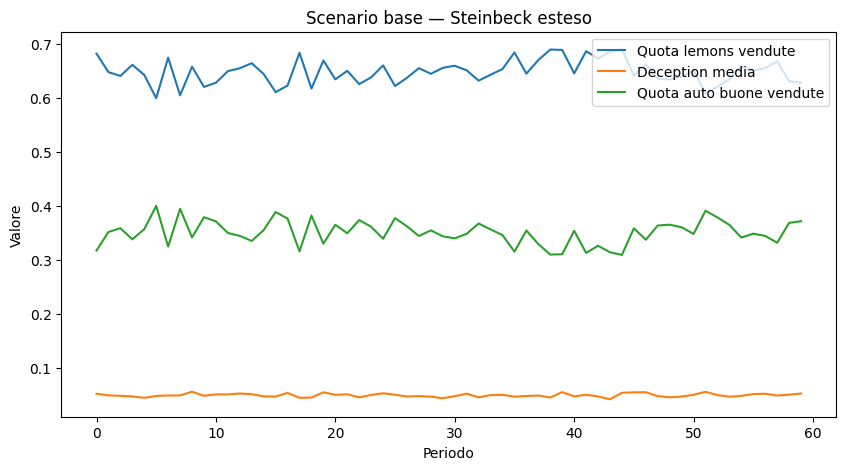

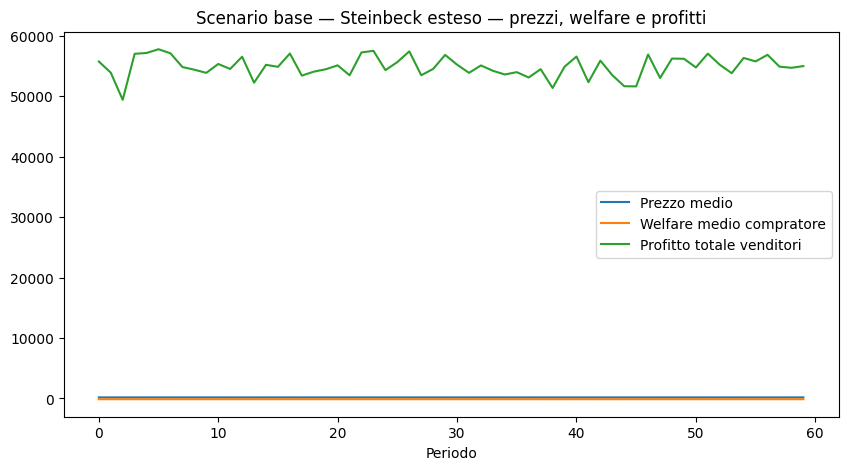

In [6]:
df_base, p_base = run_scenario("Steinbeck esteso", params, seed=42)
display(df_base.head())
scenario_card(df_base, "Scenario base — Steinbeck esteso")
plot_scenario(df_base, "Scenario base — Steinbeck esteso")


## 4. Confronto tra scenari

Confrontiamo tre mondi.

### A. Solo Akerlof
L'informazione è imperfetta, ma:
- la domanda è meno costretta,
- il venditore ha meno potere locale,
- la discriminazione di prezzo è più debole.

### B. Steinbeck esteso
Aggiungiamo:
- vulnerabilità del compratore,
- urgenza,
- opportunismo commerciale,
- pressione del venditore,
- potere locale.

### C. Steinbeck con istituzioni
Manteniamo il contesto duro, ma introduciamo:
- ispezioni,
- sanzioni,
- standard minimi,
- rimborsi parziali.

La domanda di fondo è: **quanto cambia il risultato del mercato quando cambiano le istituzioni, a parità di vulnerabilità sociale?**


In [7]:
df_akerlof, _ = run_scenario(
    "Solo Akerlof",
    params,
    seed=42,
    forced_demand=0.28,
    local_market_power=0.25,
    seller_aggressiveness=0.25,
    price_discrimination=0.18,
    lemon_push=0.45,
    institution_strength=0.05,
    inspection_probability=0.02,
    min_quality_standard=0.0,
    warranty_refund_share=0.0,
)

df_steinbeck, _ = run_scenario(
    "Steinbeck esteso",
    params,
    seed=43,
)

df_institutions, _ = run_scenario(
    "Con istituzioni",
    params,
    seed=44,
    institution_strength=0.70,
    inspection_probability=0.45,
    min_quality_standard=0.35,
    penalty_if_caught=38.0,
    warranty_refund_share=0.20,
    lemon_push=0.58,
)

df_all = pd.concat([df_akerlof, df_steinbeck, df_institutions], ignore_index=True)
final_comparison_table(df_all)


,share_lemons_sold,avg_deception,share_good_strategy,avg_price,avg_buyer_welfare,failed_trips,no_purchase,total_profit
scenario,,,,,,,,
Steinbeck esteso,0.647,0.048,0.353,175.342,-122.626,386.783,296.367,54242.094
Solo Akerlof,0.336,0.044,0.664,110.970,-26.603,270.900,327.033,20909.605
Con istituzioni,0.181,0.042,0.819,166.677,-66.432,182.050,242.450,46244.027


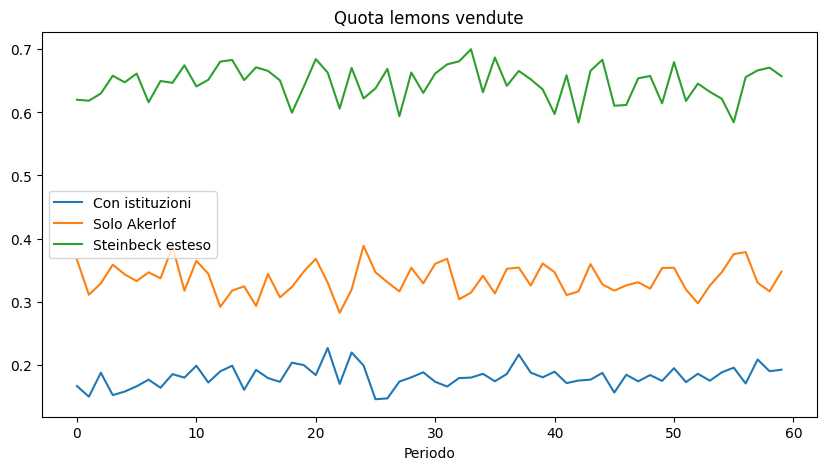

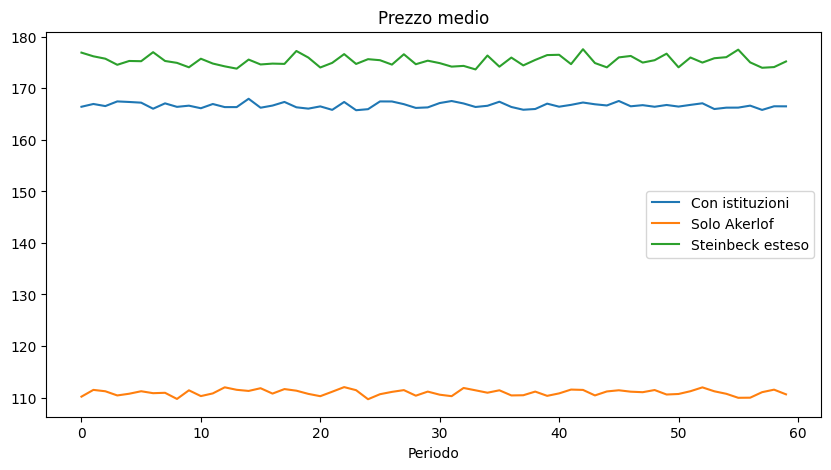

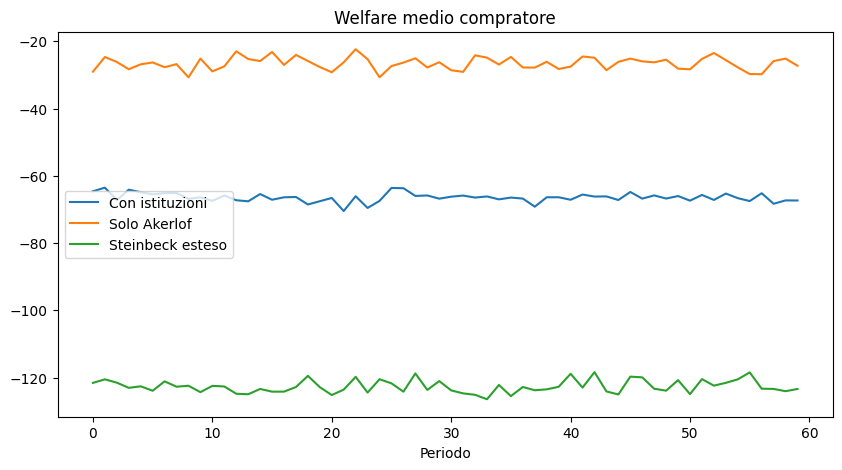

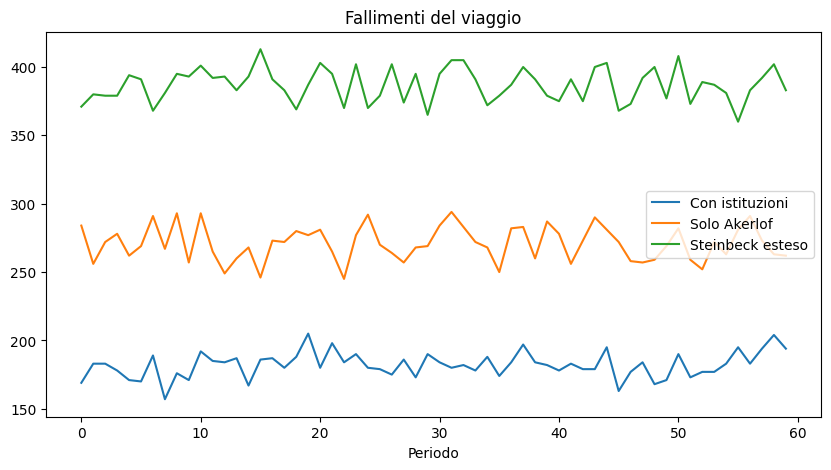

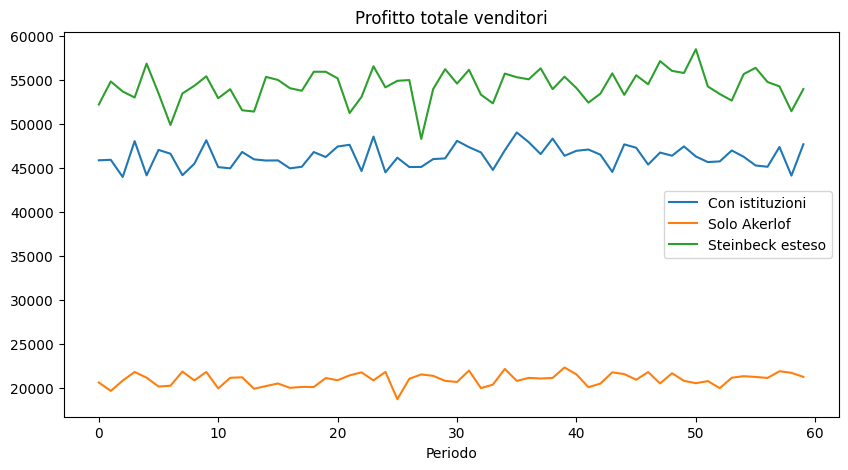

In [8]:
for metric, title in [
    ("share_lemons_sold", "Quota lemons vendute"),
    ("avg_price", "Prezzo medio"),
    ("avg_buyer_welfare", "Welfare medio compratore"),
    ("failed_trips", "Fallimenti del viaggio"),
    ("total_profit", "Profitto totale venditori"),
]:
    compare_metric(df_all, metric, title)


## 5. Lettura economica del confronto

### 5.1. La sola asimmetria informativa non basta
Lo scenario “Solo Akerlof” può generare lemons, ma spesso non produce da solo il grado di sfruttamento suggerito dal testo.

### 5.2. La domanda costretta indebolisce la disciplina del mercato
Quando il compratore **deve comprare**, la possibilità di dire “no” perde efficacia.  
Il prezzo resta alto, il lemon resta vendibile, e il welfare del compratore tende a peggiorare.

### 5.3. Potere locale + discriminazione + relazione one-shot
Questa combinazione spinge il venditore verso una strategia deliberatamente predatoria:
- il cliente non tornerà;
- il budget del cliente può essere inferito;
- la vulnerabilità del cliente può essere sfruttata.

### 5.4. Le istituzioni non eliminano il problema, ma ne cambiano l'economia
Sanzioni, standard minimi e garanzie non cancellano l'asimmetria informativa.  
Riducono però la convenienza relativa del comportamento opportunistico.


## 6. Mappa di sensibilità

Qui costruiamo una piccola **griglia di esperimenti** per osservare come cambia la quota media di lemons vendute al variare di due parametri cruciali:

- **forced_demand**;
- **institution_strength**.

Questo passaggio è utile se vuoi presentare il notebook come *paper notebook*: mostra non solo esempi, ma anche una mini-esplorazione dello spazio dei parametri.


,share_lemons_sold,avg_deception,share_good_strategy,avg_price,avg_buyer_welfare,failed_trips,no_purchase,total_profit,forced_demand,institution_strength
0,0.620,0.050,0.380,178.996,-123.742,366.767,407.600,40028.972,0.2,0.00
1,0.644,0.049,0.356,171.840,-119.002,374.883,408.567,38030.057,0.2,0.18
2,0.684,0.050,0.316,164.179,-115.432,386.133,409.433,35855.475,0.2,0.36
3,0.696,0.050,0.304,157.562,-110.007,389.900,407.317,33553.524,0.2,0.54
4,0.707,0.050,0.293,150.858,-104.456,394.750,404.517,30811.044,0.2,0.72


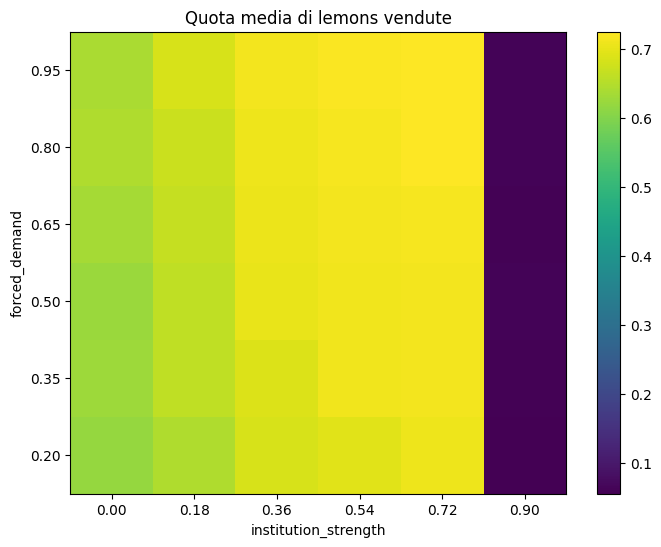

institution_strength,0.00,0.18,0.36,0.54,0.72,0.90
forced_demand,,,,,,
0.95,0.641,0.685,0.713,0.721,0.725,0.062
0.80,0.645,0.672,0.707,0.717,0.724,0.061
0.65,0.635,0.666,0.705,0.714,0.717,0.060
0.50,0.625,0.660,0.702,0.710,0.712,0.061
0.35,0.627,0.661,0.689,0.710,0.714,0.059
0.20,0.620,0.644,0.684,0.696,0.707,0.055


In [9]:
def parameter_grid(base, forced_values, institution_values, seed_start=100):
    rows = []
    k = 0
    for fd in forced_values:
        for inst in institution_values:
            df, _ = run_scenario(
                f"fd={fd:.2f}, inst={inst:.2f}",
                base,
                seed=seed_start + k,
                forced_demand=float(fd),
                institution_strength=float(inst),
                inspection_probability=max(0.02, 0.55 * float(inst)),
                min_quality_standard=0.35 * float(inst),
                warranty_refund_share=0.20 * float(inst),
            )
            s = summarize_scenario(df).iloc[0].to_dict()
            s["forced_demand"] = round(float(fd), 2)
            s["institution_strength"] = round(float(inst), 2)
            rows.append(s)
            k += 1
    return pd.DataFrame(rows)

forced_values = np.linspace(0.20, 0.95, 6)
institution_values = np.linspace(0.00, 0.90, 6)

grid_df = parameter_grid(params, forced_values, institution_values)
display(grid_df.head())

pivot = grid_df.pivot(index="forced_demand", columns="institution_strength", values="share_lemons_sold")
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:.2f}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{i:.2f}" for i in pivot.index])
ax.set_xlabel("institution_strength")
ax.set_ylabel("forced_demand")
ax.set_title("Quota media di lemons vendute")
plt.colorbar(im, ax=ax)
plt.show()

pivot.round(3)


## 7. Explorer interattivo

La cella seguente crea un piccolo explorer con slider.
È pensato per Jupyter/Notebook o JupyterLab; con **Voilà** diventa una mini-app.

Sono stati aggiunti anche gli slider per i tre parametri strutturali della classe `Params`:
- `n_buyers`
- `n_sellers`
- `periods`

**Unità di tempo.** In questo notebook **un periodo corrisponde a una settimana di mercato**: un round in cui i compratori cercano un'auto, incontrano i venditori e possono concludere o fallire l'acquisto. Quindi `periods=52` equivale a circa un anno di simulazione.

Se `ipywidgets` non è installato, il notebook mostrerà un messaggio e il resto continuerà a funzionare normalmente.


In [10]:
if HAS_WIDGETS:
    def explore(
        n_buyers=700,
        n_sellers=28,
        periods=60,
        forced_demand=0.78,
        local_market_power=0.78,
        price_discrimination=0.62,
        seller_aggressiveness=0.72,
        institution_strength=0.08,
        inspection_probability=0.05,
        min_quality_standard=0.00,
        lemon_push=0.68,
        seed=42
    ):
        df, p = run_scenario(
            "Explorer",
            params,
            seed=int(seed),
            n_buyers=int(n_buyers),
            n_sellers=int(n_sellers),
            periods=int(periods),
            forced_demand=forced_demand,
            local_market_power=local_market_power,
            price_discrimination=price_discrimination,
            seller_aggressiveness=seller_aggressiveness,
            institution_strength=institution_strength,
            inspection_probability=inspection_probability,
            min_quality_standard=min_quality_standard,
            lemon_push=lemon_push,
            warranty_refund_share=0.20 * institution_strength,
        )
        display(Markdown(
            f"**Time unit:** 1 period = 1 market week. "
            f"The current setting (`periods={int(periods)}`) represents about {int(periods)/52:.2f} years."
        ))
        display(pd.DataFrame([asdict(p)]).T.rename(columns={0: "value"}))
        scenario_card(df, "Explorer")
        plot_scenario(df, "Explorer interattivo")

    widgets.interact(
        explore,
        n_buyers=widgets.IntSlider(min=100, max=3000, step=50, value=700),
        n_sellers=widgets.IntSlider(min=5, max=200, step=1, value=28),
        periods=widgets.IntSlider(min=4, max=156, step=4, value=60),
        forced_demand=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.78),
        local_market_power=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.78),
        price_discrimination=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.62),
        seller_aggressiveness=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.72),
        institution_strength=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.08),
        inspection_probability=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.05),
        min_quality_standard=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.00),
        lemon_push=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.68),
        seed=widgets.IntSlider(min=1, max=300, step=1, value=42),
    );
else:
    print("ipywidgets non disponibile. Installa ipywidgets oppure usa il notebook come versione non interattiva.")


interactive(children=(IntSlider(value=700, description='n_buyers', max=3000, min=100, step=50), IntSlider(valu…

## 8. Come pubblicarlo online

### Opzione 1 — Notebook statico su GitHub
Metti il file `.ipynb` nel repository.  
GitHub renderizza il notebook direttamente.

### Opzione 2 — Binder
Aggiungi un piccolo `requirements.txt`, per esempio:

```txt
numpy
pandas
matplotlib
ipywidgets
voila
```

Poi apri il repository con Binder.

### Opzione 3 — Voilà
Per trasformarlo in mini-app:

```bash
pip install voila ipywidgets
voila steinbeck_lemons_abm_publishable.ipynb
```

### Suggerimento pratico
Per una versione davvero online e presentabile, puoi:
- tenere questo notebook come **versione completa**;
- affiancargli una copia più corta, pensata solo per l'explorer;
- aggiungere una prima cella con titolo, autore e breve abstract.

---

## Chiusura

Questo notebook è già abbastanza solido per essere:
- mostrato in un seminario;
- caricato online;
- usato come base per un paper notebook;
- esteso verso una versione più empirica o storicamente calibrata.
